# Baseline Recall@32: OneRec-1.7B

Aligned with the official OpenOneRec evaluation pipeline:
- Source: `github.com/Kuaishou-OneRec/OpenOneRec/benchmarks/`

**Official video task parameters** (from `eval_script.sh`):
```bash
python3 scripts/ray-vllm/evaluate.py \
    --task_types video \
    --num_beams 32 --num_return_sequences 32 \
    --num_return_thinking_sequences 1
```

**Generation flow** (from `base_generator.py`, `enable_thinking=False` + `prompt_token` path):
1. Append `<|sid_begin|>` to prompt
2. Beam search with `num_beams=32`, return 32 sequences, `max_new_tokens=3`
3. Each sequence is 3 tokens: `<s_a_X><s_b_Y><s_c_Z>`

**Evaluation** (from `utils_by_pid.py`):
1. Parse SID triples from generated text
2. Encode SID: `c1 * 8192^2 + c2 * 8192 + c3`
3. Map to PID via `sid2pid.json` with `most_popular_after_downsampling` strategy
4. Deduplicate PIDs, compute Pass@1 / Pass@32 / Recall@32 on unique PID list

**Official numbers** (Table 4, OneRec-1.7B, video task):

| Metric | Value |
|---|---|
| Pass@1 | 0.0496 |
| Pass@32 | 0.1710 |
| Recall@32 | 0.0272 |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Config ──────────────────────────────────────────────
MODEL_NAME   = "OpenOneRec/OneRec-1.7B"    # change to local path if downloaded
N_SAMPLES    = 100                          # users to evaluate (None = all)
DEVICE       = "cuda"                       # "auto", "cpu", "cuda:0", "mps"

# Evaluate on our contrastive dataset
DATASET_PATH = "/content/drive/Shareddrives/209B/valid.parquet"

# Official mapping file
SID2PID_PATH = "/content/drive/Shareddrives/209B/sid2pid.json"

# Generation params (from eval_script.sh for video task)
NUM_BEAMS           = 32
NUM_RETURN_SEQ      = 32
MAX_NEW_TOKENS      = 3    # only s_a, s_b, s_c (sid_begin is in prompt)

In [3]:
import re
import json
import random
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

## 1. Load model and tokenizer

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
    trust_remote_code=True,
)
model.eval()
print(f"Model loaded on {model.device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00000-of-00001.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

Model loaded on cuda:0


## 2. Load SID→PID mapping

Official format from `sid2pid.json`:
- Key: `str(c1 * 8192^2 + c2 * 8192 + c3)` — encoded SID
- Value: `[{"pid": int, "count": int, "count_after_downsample": int}, ...]`
- One SID may map to multiple PIDs (many-to-one in reverse)
- Strategy `most_popular_after_downsampling`: pick PID with highest `count_after_downsample`

In [11]:
CODE_MUL_1 = 8192 * 8192  # 67108864
CODE_MUL_2 = 8192

with open(SID2PID_PATH) as f:
    _raw = json.load(f)
sid2pid_map = {int(k): v for k, v in _raw.items()}
del _raw
print(f"Loaded {len(sid2pid_map):,} SID→PID entries")


def encode_sid(c1: int, c2: int, c3: int) -> int:
    """Encode (c1, c2, c3) → single int key. Matches official encode_sid()."""
    return c1 * CODE_MUL_1 + c2 * CODE_MUL_2 + c3


def sid_to_pid(c1: int, c2: int, c3: int) -> int:
    """
    Convert SID triple → PID.
    Uses 'most_popular_after_downsampling' strategy (official default).
    Returns 0 if not found.
    """
    pid_list = sid2pid_map.get(encode_sid(c1, c2, c3))
    if not pid_list:
        return 0
    max_count = max(info["count_after_downsample"] for info in pid_list)
    candidates = [info.get("pid", info.get("iid", 0))
                  for info in pid_list if info["count_after_downsample"] == max_count]
    return random.choice(candidates)

Loaded 1,519,078 SID→PID entries


## 3. Load dataset

In [12]:
df = pd.read_parquet(DATASET_PATH)
if N_SAMPLES is not None:
    df = df.sample(n=min(N_SAMPLES, len(df)), random_state=42).reset_index(drop=True)
print(f"Evaluating {len(df)} users")

Evaluating 100 users


## 4. Prompt formatting

Matches the benchmark data format:
- System: `你是一位视频推荐系统专家，擅长捕捉用户的兴趣演变。请根据历史序列推荐后续视频。`
- User: `{history SIDs}\n推荐后续视频：`
- Apply chat template + `add_generation_prompt=True`
- Append `<|sid_begin|>` token ID (176245) **manually after tokenization**

**CRITICAL**: We must NOT do `prompt_text += "<|sid_begin|>"` then `tokenizer(prompt_text)`.
The tokenizer may split the string `<|sid_begin|>` into subword pieces instead of
recognizing it as special token 176245. This causes the model to see a corrupted
prefix, all 32 beams collapse to the same recovery output, and Pass@1 == Pass@32.

Instead: tokenize the chat first via `apply_chat_template(return_tensors="pt")`,
then `torch.cat` the `<|sid_begin|>` token ID at the end.

In [14]:
SYSTEM_PROMPT = "你是一位视频推荐系统专家，擅长捕捉用户的兴趣演变。请根据历史序列推荐后续视频。"
TRAILING_INST = "\n推荐后续视频："   # most common suffix in benchmark data

# <|sid_begin|> token ID — must be appended manually, NOT via string concat
SID_BEGIN_TOKEN_ID = tokenizer.convert_tokens_to_ids("<|sid_begin|>")
print(f"<|sid_begin|> token ID: {SID_BEGIN_TOKEN_ID}")
assert SID_BEGIN_TOKEN_ID != tokenizer.unk_token_id, "FATAL: <|sid_begin|> not in tokenizer vocab!"


def sid_triple_to_str(sid):
    return f"<|sid_begin|><s_a_{int(sid[0])}><s_b_{int(sid[1])}><s_c_{int(sid[2])}><|sid_end|>"


def build_prompt_ids(hist_sids):
    """
    Build tokenized prompt with <|sid_begin|> appended as prompt_token.

    CRITICAL: We tokenize the chat prompt first, then manually append
    the <|sid_begin|> token ID. If we instead do string concat
    (prompt_text += "<|sid_begin|>") and then tokenize, the tokenizer
    may split "<|sid_begin|>" into subword pieces instead of mapping
    it to the single special token (id=176245). This causes the model
    to see garbage, all beams collapse to the same output, and
    Pass@1 == Pass@32.
    """
    hist_str = "".join(sid_triple_to_str(s) for s in hist_sids)
    user_content = hist_str + TRAILING_INST
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]
    # Tokenize the chat part
    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    encoded = tokenizer(prompt_text, return_tensors="pt")
    prompt_ids = encoded["input_ids"]
    # Manually append <|sid_begin|> token ID
    sid_token = torch.tensor([[SID_BEGIN_TOKEN_ID]], dtype=torch.long)
    prompt_ids = torch.cat([prompt_ids, sid_token], dim=1)
    return prompt_ids.to(model.device)


# ── Sanity checks ──
test_ids = build_prompt_ids(df.iloc[0]["hist_sids"])
print(f"\nPrompt length: {test_ids.shape[1]} tokens")
print(f"Last 5 token IDs: {test_ids[0, -5:].tolist()}")
print("Last 5 tokens decoded:")
for tid in test_ids[0, -5:].tolist():
    print(f"  {tid} -> {repr(tokenizer.decode([tid]))}")
print(f"\nExpected: last token = <|sid_begin|> (id={SID_BEGIN_TOKEN_ID})")

<|sid_begin|> token ID: 176245

Prompt length: 2485 tokens
Last 5 token IDs: [198, 151644, 77091, 198, 176245]
Last 5 tokens decoded:
  198 -> '\n'
  151644 -> '<|im_start|>'
  77091 -> 'assistant'
  198 -> '\n'
  176245 -> '<|sid_begin|>'

Expected: last token = <|sid_begin|> (id=176245)


## 5. Generation

Official: beam search via vLLM, `num_beams=32, num_return_sequences=32, max_new_tokens=3`.

With HuggingFace `model.generate`, beam search returns up to `num_return_sequences` candidates
(must be ≤ `num_beams`). We use `num_beams=32, num_return_sequences=32` to match exactly.

In [15]:
# Regex to extract SID codes — matches official extract_sid_codes_from_text()
SID_PATTERN = re.compile(r'<s_a_(\d+)><s_b_(\d+)><s_c_(\d+)>')


def parse_sid_from_text(text):
    """Extract (c1, c2, c3) from generated text. Returns None if not found."""
    m = SID_PATTERN.search(text)
    if m:
        return (int(m.group(1)), int(m.group(2)), int(m.group(3)))
    return None


@torch.no_grad()
def generate_candidates(prompt_ids):
    """
    Generate candidates via beam search from pre-tokenized prompt.

    Args:
        prompt_ids: tensor of shape (1, seq_len) — already includes <|sid_begin|>

    Returns:
        unique_pids: list of unique PIDs (deduplicated, ordered by beam rank)
        n_valid_parse: how many of 32 sequences parsed as valid SID
        n_valid_pid: how many parsed SIDs mapped to a real PID
    """
    n_prompt = prompt_ids.shape[1]

    outputs = model.generate(
        prompt_ids,
        max_new_tokens=MAX_NEW_TOKENS,
        num_beams=NUM_BEAMS,
        num_return_sequences=NUM_RETURN_SEQ,
        do_sample=False,
    )

    # Parse each candidate, deduplicate (first occurrence wins = best beam score)
    seen_pids = set()
    unique_pids = []
    n_valid_parse = 0
    n_valid_pid = 0

    for i in range(outputs.shape[0]):
        new_tokens = outputs[i, n_prompt:]
        text = tokenizer.decode(new_tokens, skip_special_tokens=False)
        sid = parse_sid_from_text(text)
        if sid is None:
            continue
        n_valid_parse += 1

        pid = sid_to_pid(*sid)
        if pid == 0:
            continue
        n_valid_pid += 1

        if pid not in seen_pids:
            seen_pids.add(pid)
            unique_pids.append(pid)

    return unique_pids, n_valid_parse, n_valid_pid

In [16]:
# Quick test on one user — with detailed diagnostics
test_ids = build_prompt_ids(df.iloc[0]["hist_sids"])
cands, n_parse, n_pid = generate_candidates(test_ids)

print(f"Generated: {n_parse} valid parses, {n_pid} valid PIDs, {len(cands)} unique PIDs")
print(f"Top-5 PIDs: {cands[:5]}")
print(f"Chosen PID: {df.iloc[0]['chosen_pids'][0]}")
print(f"Hit in top-32? {int(df.iloc[0]['chosen_pids'][0]) in set(cands[:32])}")

# Extra diagnostics: show raw generated tokens for first few beams
print(f"\n── Raw beam outputs (first 5) ──")
n_prompt = test_ids.shape[1]
with torch.no_grad():
    outputs = model.generate(
        test_ids, max_new_tokens=MAX_NEW_TOKENS,
        num_beams=NUM_BEAMS, num_return_sequences=min(5, NUM_RETURN_SEQ),
        do_sample=False,
    )
for i in range(outputs.shape[0]):
    new_toks = outputs[i, n_prompt:]
    ids = new_toks.tolist()
    decoded = tokenizer.decode(new_toks, skip_special_tokens=False)
    print(f"  beam[{i}] ids={ids} -> {repr(decoded)}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated: 32 valid parses, 29 valid PIDs, 29 unique PIDs
Top-5 PIDs: [7029204, 1574266, 1114116, 8062448, 3706523]
Chosen PID: 3189188
Hit in top-32? False

── Raw beam outputs (first 5) ──
  beam[0] ids=[154848, 167821, 174712] -> '<s_a_3179><s_b_7960><s_c_6659>'
  beam[1] ids=[154155, 163880, 170058] -> '<s_a_2486><s_b_4019><s_c_2005>'
  beam[2] ids=[153082, 167465, 174961] -> '<s_a_1413><s_b_7604><s_c_6908>'
  beam[3] ids=[156088, 164782, 170688] -> '<s_a_4419><s_b_4921><s_c_2635>'
  beam[4] ids=[154886, 166351, 168079] -> '<s_a_3217><s_b_6490><s_c_26>'


## 6. Metrics computation

Matches `utils_by_pid.py`:
- **Pass@K**: any of top-K predicted PIDs ∈ ground truth set?
- **Recall@K**: |top-K ∩ ground_truth| / |ground_truth|

Since our dataset has 1 chosen item per user, Recall@32 = Pass@32 (binary).

In [17]:
def compute_pass_at_k(predicted_pids, ground_truth_set, k):
    """Official: does any of top-k match any ground truth?"""
    top_k = set(pid for pid in predicted_pids[:k] if pid != 0)
    return len(top_k & ground_truth_set) > 0


def compute_recall_at_k(predicted_pids, ground_truth_set, k):
    """Official: fraction of ground truth found in top-k."""
    if not ground_truth_set:
        return 0.0
    top_k = set(pid for pid in predicted_pids[:k] if pid != 0)
    return len(top_k & ground_truth_set) / len(ground_truth_set)

## 7. Run evaluation

In [18]:
results = []

for idx in tqdm(range(len(df)), desc="Evaluating"):
    row = df.iloc[idx]
    chosen_pid = int(row["chosen_pids"][0])
    rejected_pid = int(row["rejected_pids"][0])
    ground_truth = {chosen_pid}

    prompt_ids = build_prompt_ids(row["hist_sids"])
    candidates, n_parse, n_pid = generate_candidates(prompt_ids)

    results.append({
        "uid": row["uid"],
        "chosen_pid": chosen_pid,
        "pass_at_1":   compute_pass_at_k(candidates, ground_truth, k=1),
        "pass_at_32":  compute_pass_at_k(candidates, ground_truth, k=32),
        "recall_at_32": compute_recall_at_k(candidates, ground_truth, k=32),
        "rejected_hit_at_32": compute_pass_at_k(candidates, {rejected_pid}, k=32),
        "n_valid_parses": n_parse,
        "n_valid_pids": n_pid,
        "n_unique_pids": len(candidates),
    })

results_df = pd.DataFrame(results)
print(f"\nDone. {len(results_df)} users evaluated.")

Evaluating: 100%|██████████| 100/100 [03:09<00:00,  1.90s/it]


Done. 100 users evaluated.


## 8. Results

In [19]:
print("=" * 60)
print("Baseline: OneRec-1.7B  (official eval protocol)")
print("=" * 60)
print(f"  N users evaluated      : {len(results_df)}")
print(f"  Generation             : beam_search, num_beams={NUM_BEAMS},")
print(f"                           num_return_sequences={NUM_RETURN_SEQ},")
print(f"                           max_new_tokens={MAX_NEW_TOKENS}")
print()
print("── Recommendation Metrics ─────────────────────────────")
print(f"  Pass@1                 : {results_df['pass_at_1'].mean():.4f}")
print(f"  Pass@32                : {results_df['pass_at_32'].mean():.4f}")
print(f"  Recall@32              : {results_df['recall_at_32'].mean():.4f}")
print()
print("── Reference (Table 4, video_test, OneRec-1.7B) ───────")
print(f"  Pass@1                 : 0.0496")
print(f"  Pass@32                : 0.1710")
print(f"  Recall@32              : 0.0272")
print()
print("── Sanity Checks ──────────────────────────────────────")
print(f"  Rejected hit@32        : {results_df['rejected_hit_at_32'].mean():.4f}")
print(f"  Mean valid parses      : {results_df['n_valid_parses'].mean():.1f} / {NUM_RETURN_SEQ}")
print(f"  Mean valid PIDs        : {results_df['n_valid_pids'].mean():.1f} / {NUM_RETURN_SEQ}")
print(f"  Mean unique PIDs       : {results_df['n_unique_pids'].mean():.1f}")

Baseline: OneRec-1.7B  (official eval protocol)
  N users evaluated      : 100
  Generation             : beam_search, num_beams=32,
                           num_return_sequences=32,
                           max_new_tokens=3

── Recommendation Metrics ─────────────────────────────
  Pass@1                 : 0.0100
  Pass@32                : 0.0100
  Recall@32              : 0.0100

── Reference (Table 4, video_test, OneRec-1.7B) ───────
  Pass@1                 : 0.0496
  Pass@32                : 0.1710
  Recall@32              : 0.0272

── Sanity Checks ──────────────────────────────────────
  Rejected hit@32        : 0.0400
  Mean valid parses      : 32.0 / 32
  Mean valid PIDs        : 21.5 / 32
  Mean unique PIDs       : 21.5


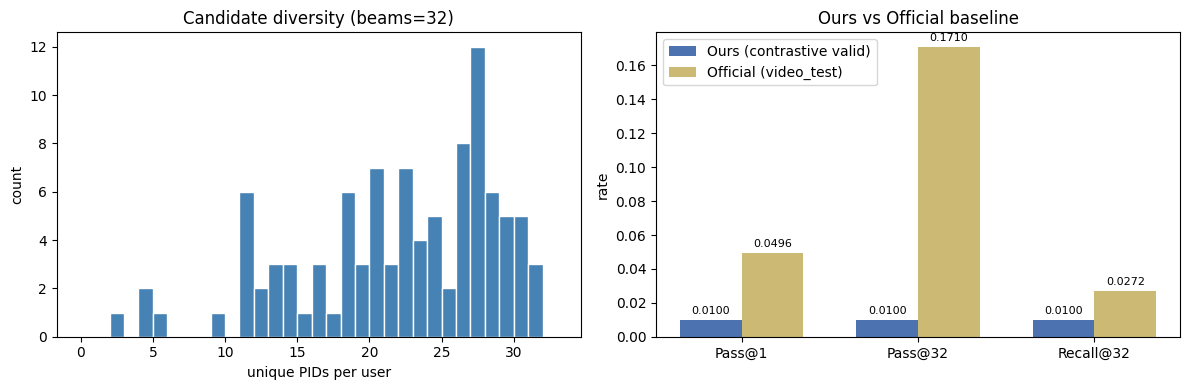

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unique candidates distribution
axes[0].hist(results_df["n_unique_pids"], bins=range(0, NUM_RETURN_SEQ + 2),
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("unique PIDs per user")
axes[0].set_ylabel("count")
axes[0].set_title(f"Candidate diversity (beams={NUM_BEAMS})")

# Metrics comparison with official
labels = ["Pass@1", "Pass@32", "Recall@32"]
ours = [
    results_df["pass_at_1"].mean(),
    results_df["pass_at_32"].mean(),
    results_df["recall_at_32"].mean(),
]
official = [0.0496, 0.1710, 0.0272]

x = np.arange(len(labels))
w = 0.35
bars1 = axes[1].bar(x - w/2, ours, w, label="Ours (contrastive valid)", color="#4c72b0")
bars2 = axes[1].bar(x + w/2, official, w, label="Official (video_test)", color="#ccb974")

for bar, v in zip(bars1, ours):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=8)
for bar, v in zip(bars2, official):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("rate")
axes[1].set_title("Ours vs Official baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

## Notes

**Differences from official eval that may affect numbers:**

1. **Backend**: official uses vLLM; we use HuggingFace `model.generate`. Beam search
   implementation may differ slightly.
2. **Ground truth**: official `video_test` has 10 target items per user;
   our contrastive dataset has 1 chosen item. So our Recall@32 = Pass@32 (binary),
   while official Recall@32 is a fraction out of 10.
3. **Trailing instruction**: benchmark data has 5 different suffixes; we always use
   `推荐后续视频：`. This shouldn't matter much for beam search over SID tokens.
4. **User population**: our contrastive valid set is filtered (gap > 1.5, has pos+neg items)
   vs. official video_test which has all benchmark users.